# Plots
Loads all scenario results and produces all figures.
**Run all scenario notebooks first.**

## Load all scenario results

In [18]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

data_folder = Path.cwd().parent / 'data' / 'processed'

scenario_files = {
    'Baseline':   '00_baseline.pkl',
    'Best':       '01_best.pkl',
    'Worst':      '02_worst.pkl',
    'Socio':      '03_socio.pkl',
    'Techno':     '04_techno.pkl',
}

scenarios = {}
for name, fname in scenario_files.items():
    with open(data_folder / fname, 'rb') as f:
        scenarios[name] = pickle.load(f)
    print(f'Loaded: {name}')

# Shared
baseline   = scenarios['Baseline']
years      = baseline['years']
plot_years = baseline['plot_years']

# Color palette
sc_colors = {
    'Baseline': '#4a4a4a',
    'Best':     '#1a5c3a',
    'Worst':    '#8B1A1A',
    'Socio':    '#1B4F8A',
    'Techno':   '#0D6B5E',
}

wsa_years  = list(baseline['wsa_production'].keys())
wsa_values = [v * 1e6 for v in baseline['wsa_production'].values()]

Loaded: Baseline
Loaded: Best
Loaded: Worst
Loaded: Socio
Loaded: Techno


## 1. Total in-use steel stock — baseline

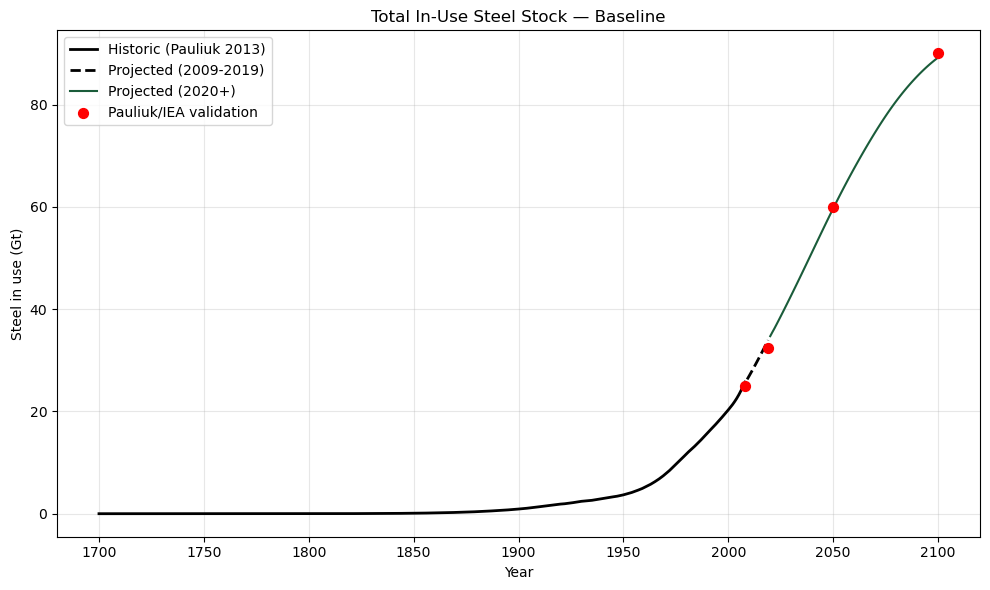

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
stock_df = baseline['stock_df']
hist   = stock_df[stock_df['type']=='historic']
recent = stock_df[stock_df['type']=='recent']
pred   = stock_df[stock_df['type']=='predicted']
ax.plot(hist['year'],   hist['total_stock']/1e9, color='black',   linewidth=2,   label='Historic (Pauliuk 2013)')
ax.plot(recent['year'], recent['total_stock']/1e9, color='black', linewidth=2, linestyle='--', label='Projected (2009-2019)')
ax.plot(pred['year'],   pred['total_stock']/1e9,  color='#1a5c3a', linewidth=1.5, label='Projected (2020+)')
ax.scatter([2008, 2019, 2050, 2100], [25, 32.3, 60, 90], color='red', zorder=5, s=50, label='Pauliuk/IEA validation')
ax.set_xlabel('Year'); ax.set_ylabel('Steel in use (Gt)')
ax.set_title('Total In-Use Steel Stock — Baseline')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Total steel stock — all scenarios

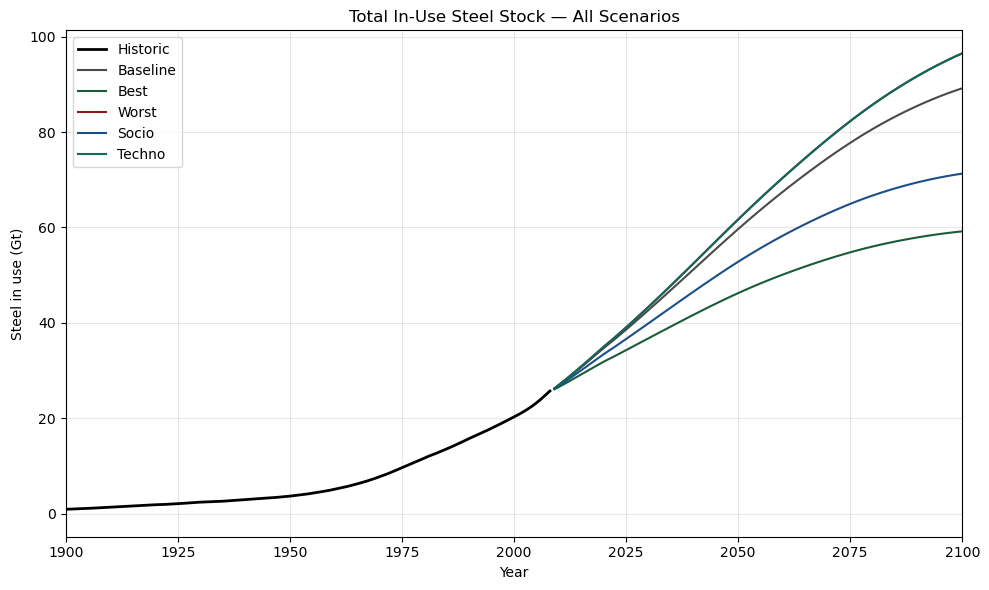

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
for name, sc in scenarios.items():
    df   = sc['stock_df']
    pred = df[df['type'].isin(['recent','predicted'])]
    hist = df[df['type']=='historic']
    if name == 'Baseline':
        ax.plot(hist['year'], hist['total_stock']/1e9, color='black', linewidth=2, label='Historic')
    ax.plot(pred['year'], pred['total_stock']/1e9, color=sc_colors[name], linewidth=1.5, label=name)
#ax.scatter([2008,2019,2050,2100],[25,32.3,60,90],color='red',zorder=5,s=50,label='Validation')
ax.set_xlabel('Year'); ax.set_ylabel('Steel in use (Gt)')
ax.set_title('Total In-Use Steel Stock — All Scenarios')
ax.set_xlim(1900, 2100)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Total crude steel needed vs WSA — baseline

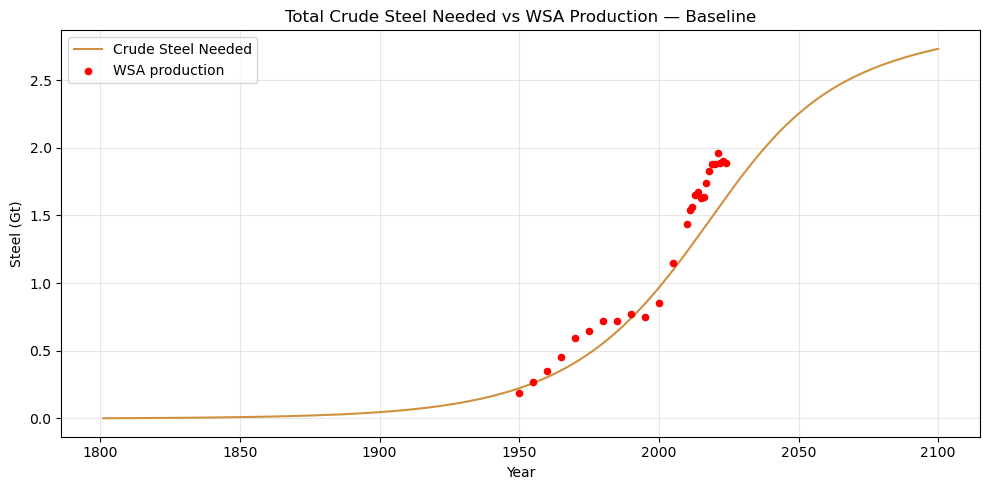

In [21]:
results = baseline['results']
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results['Year'], results['total_steel_needed']/1e9, label='Crude Steel Needed', color='#cf9140')
ax.scatter(wsa_years, [v/1e9 for v in wsa_values], color='red', s=20, zorder=5, label='WSA production')
ax.set_xlabel('Year'); ax.set_ylabel('Steel (Gt)')
ax.set_title('Total Crude Steel Needed vs WSA Production — Baseline')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Steel supply transition — baseline

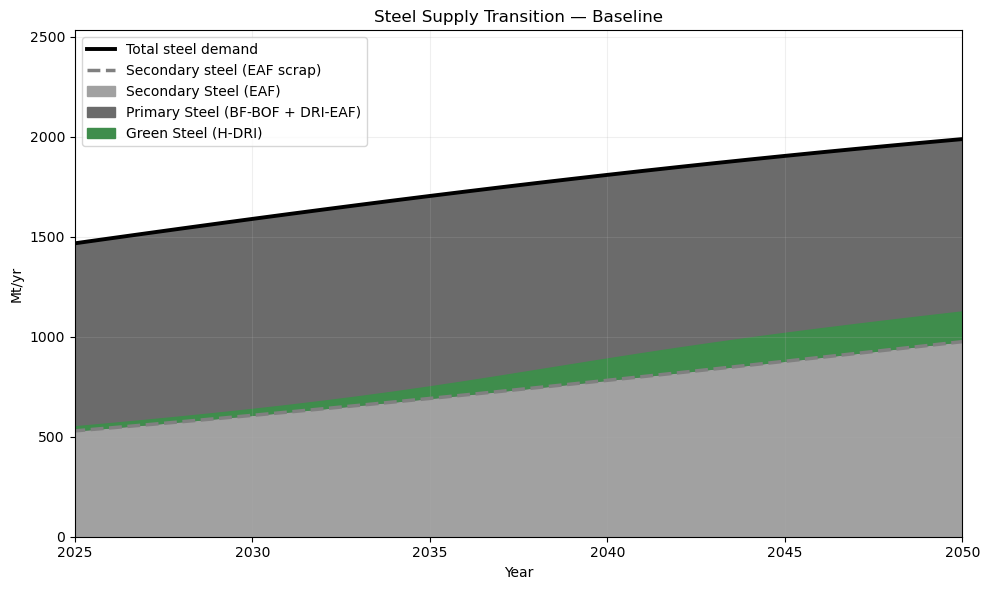

In [22]:
eaf  = baseline['future']['scrap_supply'].values / 1e6
bf   = baseline['production']['BF Production']  / 1e6
dri  = baseline['production']['DRI Production'] / 1e6
td   = baseline['future']['total_inflow'].values / 1e6

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(plot_years, td,  color='black', linewidth=2.8, label='Total steel demand')
ax.plot(plot_years, eaf, color='gray',  linewidth=2.5, linestyle='--', label='Secondary steel (EAF scrap)')
ax.fill_between(plot_years, 0,   eaf,         color='#A1A1A1', alpha=1.0, label='Secondary Steel (EAF)')
ax.fill_between(plot_years, eaf, eaf+dri+bf,  color='#6b6b6b', alpha=1.0, label='Primary Steel (BF-BOF + DRI-EAF)')
ax.fill_between(plot_years, eaf, eaf+dri,     color='#3f8d4c', alpha=1.0, label='Green Steel (H-DRI)')
ax.set_title('Steel Supply Transition — Baseline')
ax.set_xlabel('Year'); ax.set_ylabel('Mt/yr')
ax.set_ylim(0); ax.set_xlim(2025, 2050); ax.legend(loc='upper left'); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

## 5. CO2 emissions — all scenarios

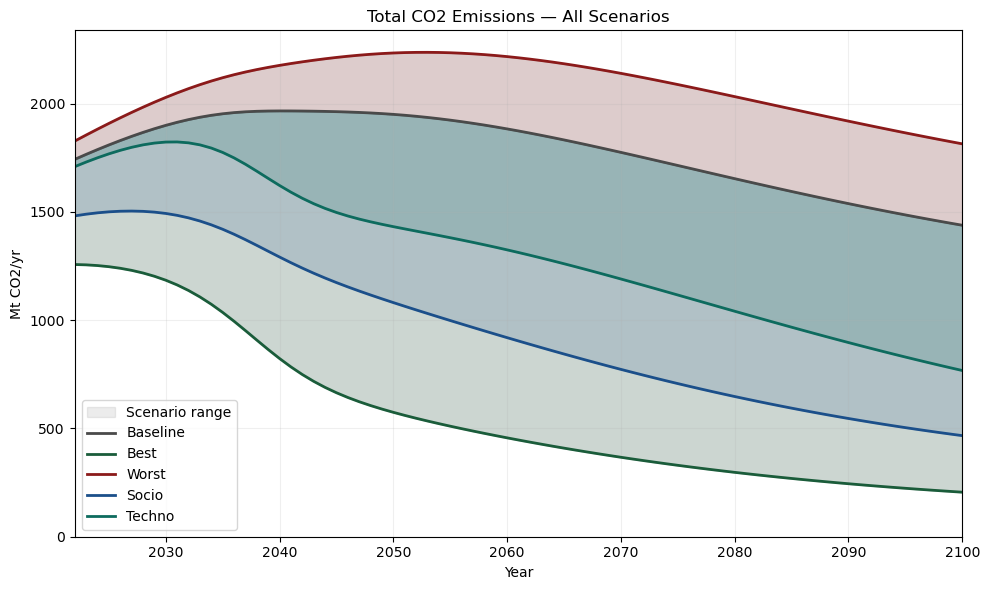

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_years = baseline['plot_years']

# Get emissions arrays for all scenarios
em = {name: sc['emissions']['Total Emissions'] for name, sc in scenarios.items()}

# Fill between worst and best to show full range
ax.fill_between(plot_years, em['Worst'], em['Best'],
                alpha=0.15, color='gray', label='Scenario range')

# Fill between each scenario and baseline
for name, sc in scenarios.items():
    if name == 'Baseline':
        continue
    color = sc_colors[name]
    ax.fill_between(plot_years, em['Baseline'], em[name],
                    alpha=0.15, color=color)

# Plot lines on top
for name, sc in scenarios.items():
    ax.plot(plot_years, sc['emissions']['Total Emissions'],
            color=sc_colors[name], linewidth=2, label=name)

ax.set_title('Total CO2 Emissions — All Scenarios')
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO2/yr')
ax.set_ylim(0); ax.set_xlim(2022, 2100)
ax.legend(); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

## 6. CO2 by route — baseline

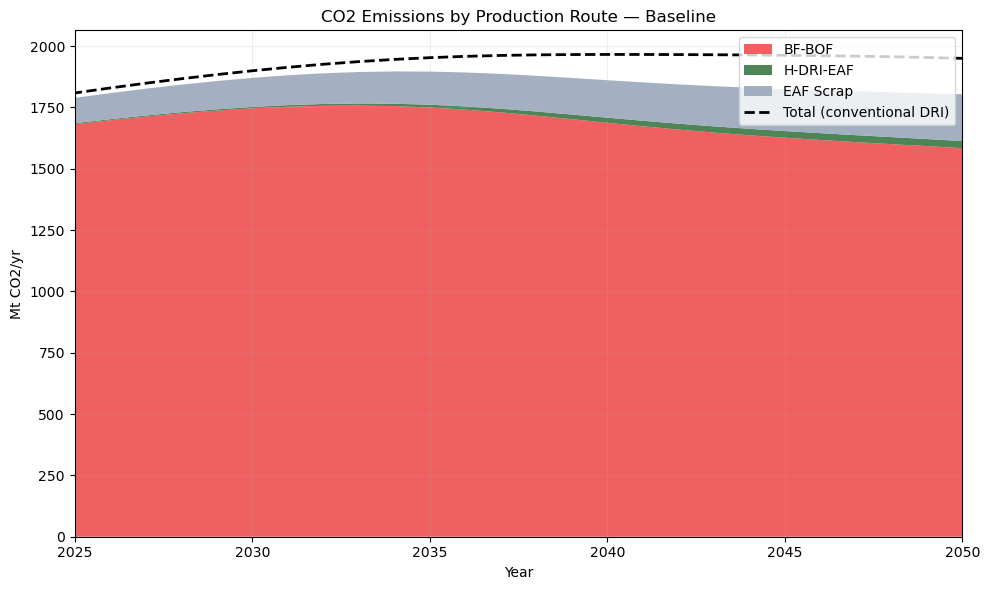

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
em = baseline['emissions']
bf_em  = em['BF Emissions']
dri_em = em['Green DRI Emissions']
eaf_em = em['EAF Emissions']
dri_conv_total = em['Total Emissions']
ax.stackplot(plot_years, bf_em, dri_em, eaf_em,
             labels=['BF-BOF','H-DRI-EAF','EAF Scrap'],
             colors=['#ef4444','#2e7038','#94a3b8'], alpha=0.85)
ax.plot(plot_years, dri_conv_total, color='black', linewidth=2, linestyle='--', label='Total (conventional DRI)', zorder=5)
ax.set_title('CO2 Emissions by Production Route — Baseline')
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO2/yr')
ax.set_ylim(0); ax.set_xlim(2025, 2050); ax.legend(loc='upper right'); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

## 7. Hydrogen demand — all scenarios

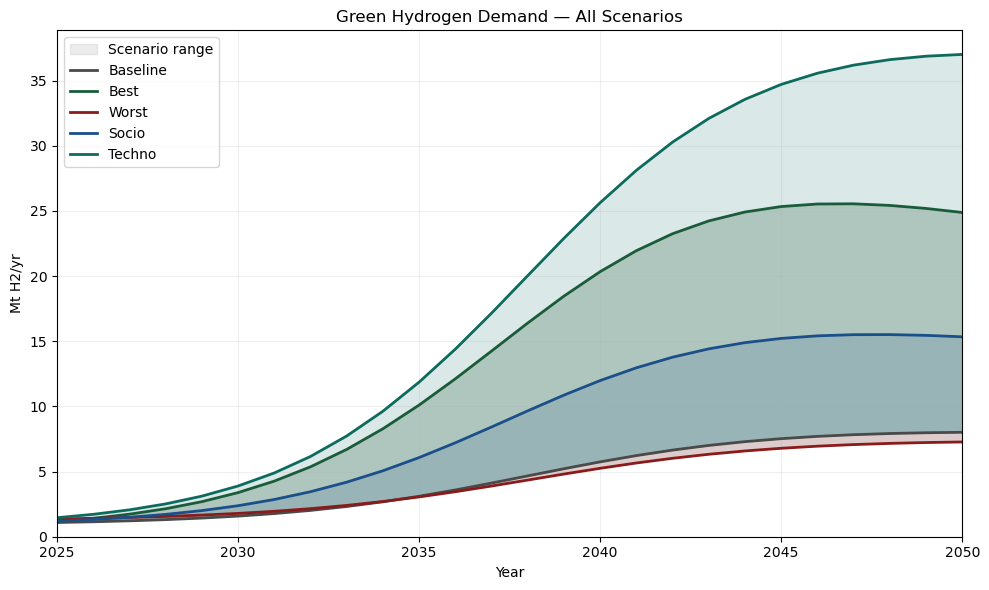

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_years = baseline['plot_years']
h2 = {name: sc['h2']['H2 Demand (Mt)'] for name, sc in scenarios.items()}

# Fill between worst and best
ax.fill_between(plot_years, h2['Worst'], h2['Best'],
                alpha=0.15, color='gray', label='Scenario range')

# Fill between each scenario and baseline
for name, sc in scenarios.items():
    if name == 'Baseline':
        continue
    ax.fill_between(plot_years, h2['Baseline'], h2[name],
                    alpha=0.15, color=sc_colors[name])

# Plot lines on top
for name, sc in scenarios.items():
    ax.plot(plot_years, sc['h2']['H2 Demand (Mt)'],
            color=sc_colors[name], linewidth=2, label=name)

ax.set_title('Green Hydrogen Demand — All Scenarios')
ax.set_xlabel('Year'); ax.set_ylabel('Mt H2/yr')
ax.set_ylim(0); ax.set_xlim(2025, 2050)
ax.legend(); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

## 8. Electrolyzer capacity — baseline

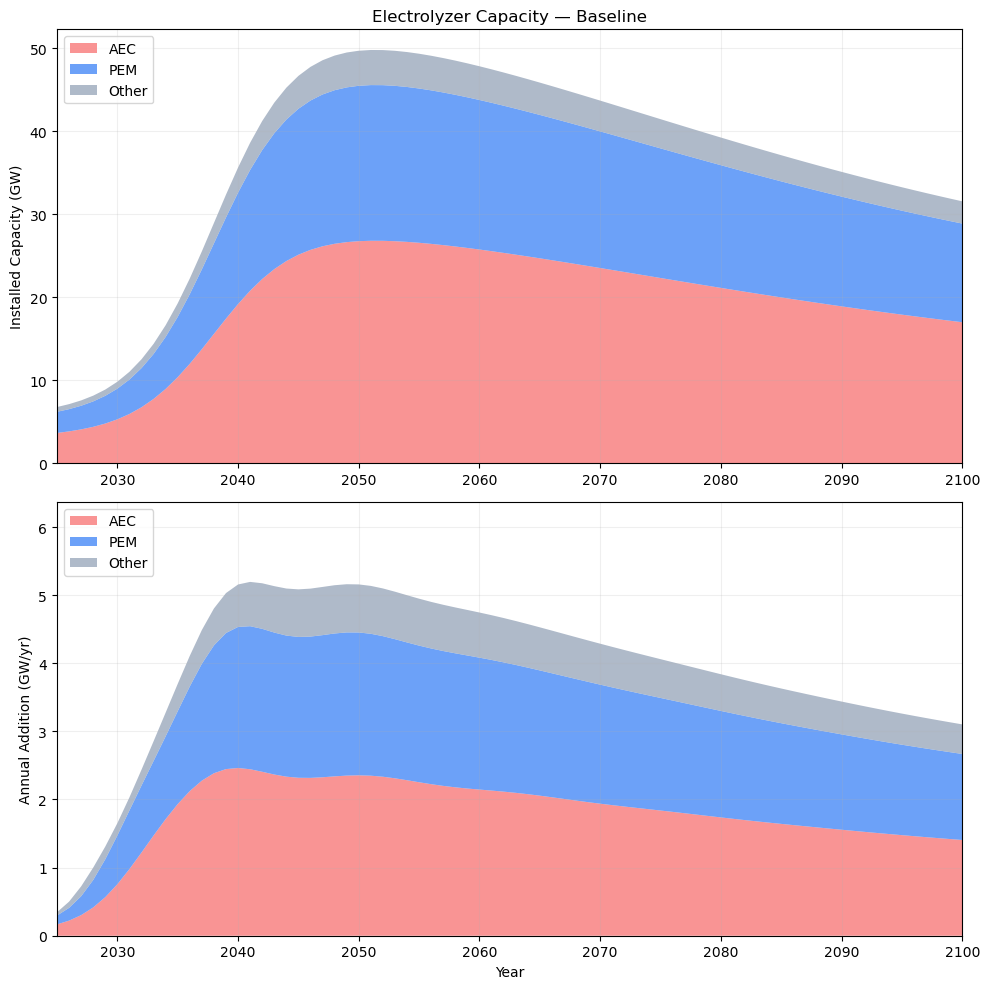

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))
cap = baseline['cap_results']; dsm = baseline['dsm_elec']
axes[0].stackplot(years, cap['AEC'], cap['PEM'], cap['Other'],
                  labels=['AEC','PEM','Other'], colors=['#f87171','#3b82f6','#94a3b8'], alpha=0.75)
axes[0].set_ylabel('Installed Capacity (GW)'); axes[0].set_title('Electrolyzer Capacity — Baseline')
axes[0].legend(loc='upper left')
axes[1].stackplot(years, dsm['i_AEC'], dsm['i_PEM'], dsm['i_Other'],
                  labels=['AEC','PEM','Other'], colors=['#f87171','#3b82f6','#94a3b8'], alpha=0.75)
axes[1].set_ylabel('Annual Addition (GW/yr)'); axes[1].set_xlabel('Year')
axes[1].legend(loc='upper left')
for ax in axes: ax.grid(True, alpha=0.2); ax.set_xlim(years[3], years[-1])
plt.tight_layout(); plt.show()

## 9. Nickel demand — all scenarios

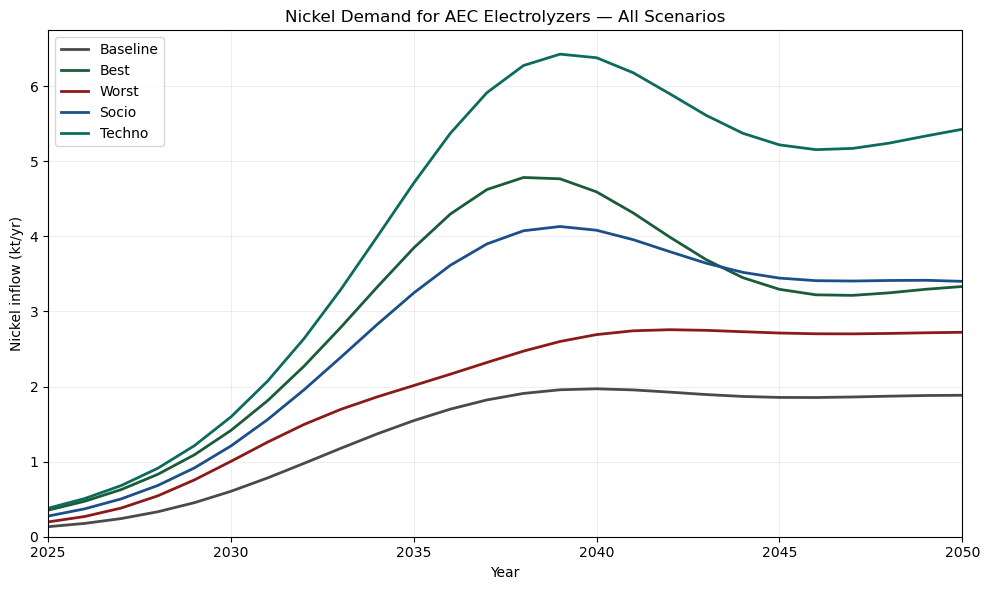

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

for name, sc in scenarios.items():
    ax.plot(sc['years'], sc['materials']['nickel_inflow'],
            color=sc_colors[name], linewidth=2, label=name)

ax.set_title('Nickel Demand for AEC Electrolyzers — All Scenarios')
ax.set_xlabel('Year'); ax.set_ylabel('Nickel inflow (kt/yr)')
ax.set_ylim(0); ax.set_xlim(2025, 2050); ax.legend(); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

## 10. Iridium demand vs supply constraint — all scenarios

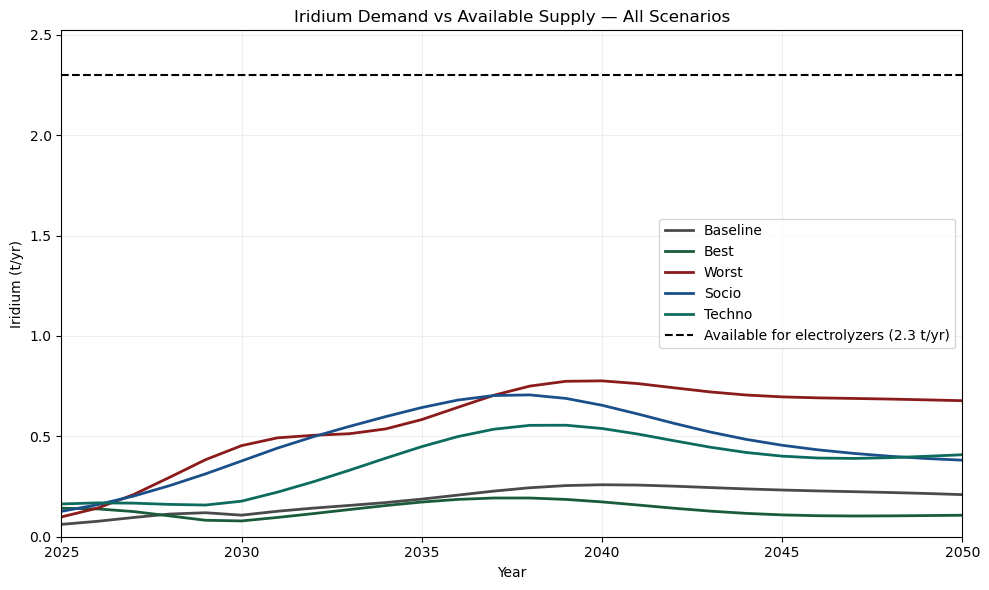

In [28]:
iridium_supply = 7.3; other_demand = 5.0; available = iridium_supply - other_demand

fig, ax = plt.subplots(figsize=(10, 6))
for name, sc in scenarios.items():
    ir = sc['materials']['iridium_inflow'] * 1000  # kt to t
    ax.plot(sc['years'], ir, color=sc_colors[name], linewidth=2, label=name)
ax.axhline(available, linestyle='--', color='black', linewidth=1.5,
           label=f'Available for electrolyzers ({available:.1f} t/yr)')
#ax.axhline(iridium_supply, linestyle=':', color='gray', linewidth=1.5,
#           label=f'Annual supply ({iridium_supply} t/yr)')
ax.set_title('Iridium Demand vs Available Supply — All Scenarios')
ax.set_xlabel('Year'); ax.set_ylabel('Iridium (t/yr)')
ax.set_ylim(0); ax.set_xlim(2025, 2050); ax.legend(); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

## 11. PGM demand (Pt + Ir) — all scenarios

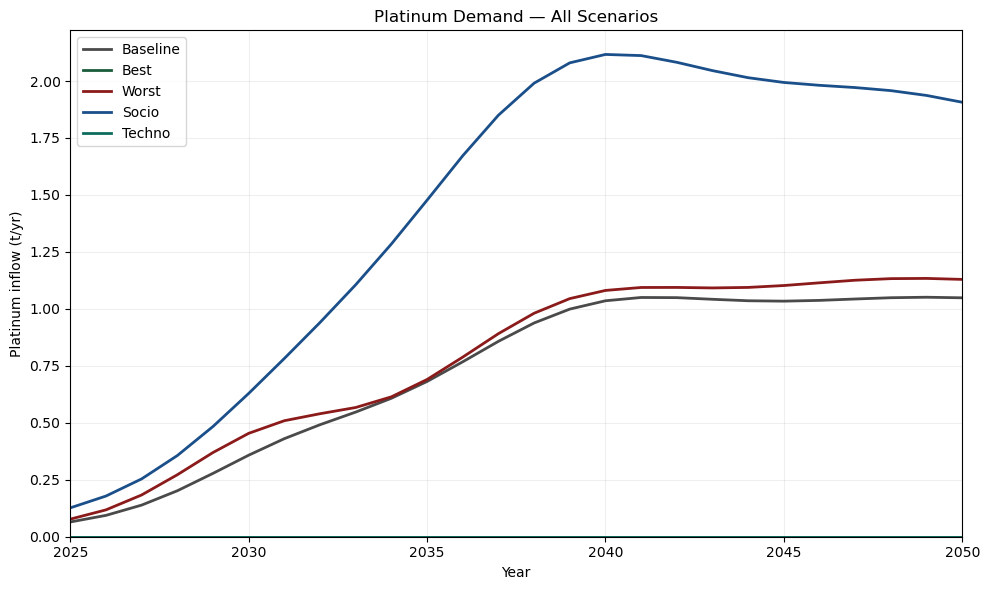

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
for name, sc in scenarios.items():
    pt = sc['materials']['platinum_inflow'] * 1000  # kt → t
    ax.plot(sc['years'], pt, color=sc_colors[name], linewidth=2, label=name)
ax.set_title('Platinum Demand — All Scenarios')
ax.set_xlabel('Year'); ax.set_ylabel('Platinum inflow (t/yr)')
ax.set_ylim(0); ax.set_xlim(2025, 2050); ax.legend(); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

## 12. Summary table at 2050

In [17]:
rows = []
for name, sc in scenarios.items():
    yrs = sc['years']
    idx = np.where(yrs == 2050)[0][0]
    rows.append({
        'Scenario':            name,
        'Stock 2050 (Gt)':     sc['stock_df'][sc['stock_df']['year']==2050]['total_stock'].values[0]/1e9,
        'H-DRI share 2050 (%)':sc['params']['dri_share_2050']*100,
        'CO2 2050 (Mt)':       sc['emissions']['Total Emissions'][idx],
        'H2 2050 (Mt)':        sc['h2']['H2 Demand (Mt)'][idx],
        'Ni 2050 (kt)':        sc['materials']['nickel_inflow'][idx],
        'Ir 2050 (t)':         sc['materials']['iridium_inflow'][idx]*1000,
    })
df_summary = pd.DataFrame(rows).set_index('Scenario').round(2)
print(df_summary.to_string())

          Stock 2050 (Gt)  H-DRI share 2050 (%)  CO2 2050 (Mt)  H2 2050 (Mt)  Ni 2050 (kt)  Ir 2050 (t)
Scenario                                                                                               
Baseline            59.67                  15.0        1950.09          8.01          1.88         0.21
Best                46.24                 100.0         574.33         24.88          3.33         0.11
Worst               61.68                  10.0        2233.49          7.27          2.72         0.68
Socio               52.81                  40.0        1080.97         15.34          3.40         1.91
Techno              61.68                  70.0        1431.59         37.01          5.43         0.18
